In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper



In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)

arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [4]:
arxiv.invoke("what is attention is all you need")

HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=what+is+attention+is+all+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)

In [8]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [9]:
import time

try:
    result = wiki.invoke("machine learning")
    print(result)
except Exception as e:
    print(f"Error: {e}")
    print("Wikipedia API is temporarily unavailable. Trying alternative query...")
    time.sleep(2)
    try:
        result = wiki.invoke("artificial intelligence")
        print(result)
    except Exception as e2:
        print(f"Still having issues: {e2}")
        print("Using a simpler query...")
        try:
            result = wiki.invoke("AI")
            print(result)
        except Exception as e3:
            print(f"Wikipedia API is not responding properly: {e3}")

Error: Expecting value: line 1 column 1 (char 0)
Wikipedia API is temporarily unavailable. Trying alternative query...
Page: Artificial intelligence
Summary: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chan


In [6]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANG_CHAIN_API_KEY"] = os.getenv("LANG_CHAIN_API_KEY")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_agent"


python-dotenv could not parse statement starting at line 8


In [10]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [11]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\hp\AppData\Local\Temp\ipykernel_9796\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [12]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'Emerging AI: Roundup for March and April 2025 - Peterson Technology Partners',
  'url': 'https://www.ptechpartners.com/2025/04/29/emerging-ai-roundup-for-march-and-april-2025/',
  'content': 'On the subject of benchmarking, Meta drew fire in April when it came to light that they’d selectively tested some Llama models, making them appear stronger than they actually are. This is further evidence of the need for companies to establish their own benchmarks and not trust self-reported findings. \n\nThings are changing fast, and as ever, it can be overwhelming for companies. \n\nTo help you stay on top of it all, consider PTP. We have over 27 years of experience in tech recruiting, with a best-in-class ML/AI talent pipeline, onshore, nearshore, or off—for whatever your specific AI needs may require.  \n\nThat’s it for the AI news for March and April 2025, or at least what we had room to cover! [...] This echoes the words of others—like OpenAI’s Sam Altman (“Systems that start to 

In [13]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily,add,divide,multiply]

In [14]:
# Initialize my LLM model

from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [15]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. I need to figure out which tool to use here. Let me check the available functions.\n\nThere\'s the Tavily Search Results JSON function, which is described as a search engine optimized for current events. That sounds perfect for recent news. The other tools like Arxiv and Wikipedia are more for academic papers and general knowledge, not the latest news. The math functions are definitely not relevant here.\n\nSo I should use the tavily_search_results_json function. The input needs to be a search query. The user\'s query is "recent AI News", so I\'ll use that as the search term. Let me make sure the parameters are correct. The function requires a "query" parameter, which I have. \n\nI need to structure the tool call properly. The name of the function is tavily_search_results_json, and the arguments should be a JSON object with the query. Let me double-check the syntax. Yes, the requ

In [16]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI News'},
  'id': '2p9hg304b',
  'type': 'tool_call'}]

In [17]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

e:\RAG AGENTIC AI\AGENTIC_AI_WITH_LANGGRAPH\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


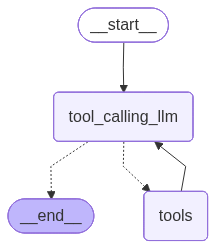

In [18]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [19]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fx1gr2sqm)
 Call ID: fx1gr2sqm
  Args:
    query: top 10 recent AI news March 3rd 2025
  add (fmm3kzmyk)
 Call ID: fmm3kzmyk
  Args:
    a: 5
    b: 5
  multiply (nsgqa0nw0)
 Call ID: nsgqa0nw0
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Highlights for March 28th, 2025", "url": "https://www.linkedin.com/pulse/ai-news-highlights-march-28th-2025-grok-ai-bpzle", "content": "The headline grabber was xAI’s acquisition of X, announced by Elon Musk. This all-stock deal pegs xAI at $80 billion and X at $33 billion (after accounting for $12 billion in debt). Musk’s post, racking up 26 

In [20]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, these systems learn patterns and make decisions based on data. Key aspects include:

1. **Supervised Learning**: Using labeled data to train models (e.g., predicting house prices based on historical data).
2. **Unsupervised Learning**: Finding hidden patterns in unlabeled data (e.g., clustering customers by behavior).
3. **Reinforcement Learning**: Learning optimal actions through trial and error with rewards/penalties (e.g., game-playing AI).

Applications range from image recognition to recommendation systems. For a deeper dive, I can look up specific details or examples. Would you like me to explore 

In [21]:
# Agent Memory

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (zkajeaxx9)
 Call ID: zkajeaxx9
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The sum of 5 and 8 is **13**.


In [23]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

The user has asked to divide a number by 5, but the specific number to divide is not provided in the current context. To proceed, I need the explicit value to perform the division.

Please provide the number you would like to divide by 5.


In [24]:
# Memory Saver

# LangGraph can use a checkpointer to automatically save the graph state after each step.
# this is build in persistence layer gives us memory , allowing langgraph to pick up from the last state update
# one of the easiest checkpointers to use is the memory save an in memory key value store for graph state.

# all we need to do is simply compile the graph with check pointer and our graph has memory

In [25]:
### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


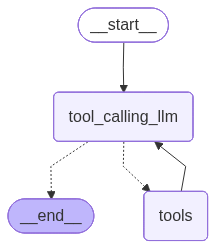

In [26]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [27]:
## Specify the thread

config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (f4ntcb9r0)
 Call ID: f4ntcb9r0
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.


In [28]:
messages = [HumanMessage(content="add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (f4ntcb9r0)
 Call ID: f4ntcb9r0
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (8npndrq7g)
 Call ID: 8npndrq7g
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The sum of 25 and 25 is **50**.


In [29]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (f4ntcb9r0)
 Call ID: f4ntcb9r0
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (8npndrq7g)
 Call ID: 8npndrq7g
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The sum of 25 and 25 is **50**.
================================ Human Message ================